<a href="https://colab.research.google.com/github/splakplutoy/tugas-sisdas-cv/blob/main/tugas_sisdas_cv_training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install kagglehub -q
import kagglehub
import os

kagglehub.login()

print("\nMengunduh dataset...")
dataset_path = kagglehub.dataset_download("ravirajsinh45/real-life-industrial-dataset-of-casting-product")

print(f"Data berhasil diunduh dan siap digunakan di folder: {dataset_path}")

print("\nIsi folder dataset:")
os.listdir(dataset_path)


Mengunduh dataset...


100%|██████████| 100M/100M [00:00<00:00, 209MB/s] 

Extracting files...


Data berhasil diunduh dan siap digunakan di folder: /root/.cache/kagglehub/datasets/ravirajsinh45/real-life-industrial-dataset-of-casting-product/versions/2

Isi folder dataset:


['casting_512x512', 'casting_data']

Kaggle credentials set.
Kaggle credentials successfully validated.


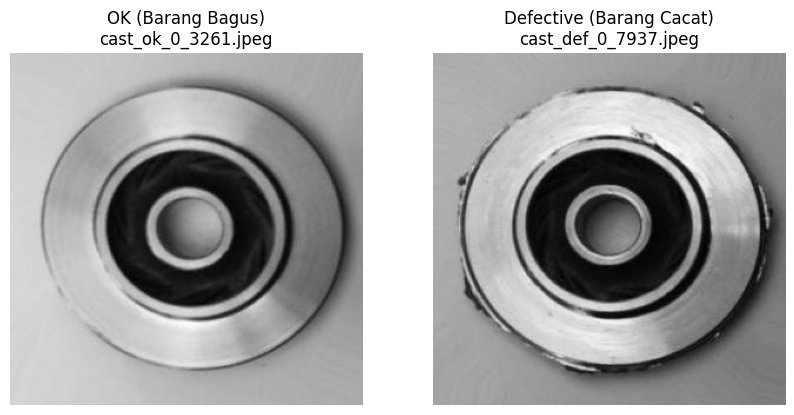

In [ ]:
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Alamat folder gambar training
base_dir = '/root/.cache/kagglehub/datasets/ravirajsinh45/real-life-industrial-dataset-of-casting-product/versions/2/casting_data/casting_data/train'
ok_dir = os.path.join(base_dir, 'ok_front')
def_dir = os.path.join(base_dir, 'def_front')

# Mengambil 1 file gambar secara acak dari masing-masing kelas
ok_img_name = os.listdir(ok_dir)[0]
def_img_name = os.listdir(def_dir)[0]

ok_img_path = os.path.join(ok_dir, ok_img_name)
def_img_path = os.path.join(def_dir, def_img_name)

# Menampilkan gambar berdampingan
fig, ax = plt.subplots(1, 2, figsize=(10, 5))

ax[0].imshow(mpimg.imread(ok_img_path), cmap='gray')
ax[0].set_title(f'OK (Barang Bagus)\n{ok_img_name}')
ax[0].axis('off')

ax[1].imshow(mpimg.imread(def_img_path), cmap='gray')
ax[1].set_title(f'Defective (Barang Cacat)\n{def_img_name}')
ax[1].axis('off')

plt.show()

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os

base_dir = '/root/.cache/kagglehub/datasets/ravirajsinh45/real-life-industrial-dataset-of-casting-product/versions/2/casting_data/casting_data'
train_dir = os.path.join(base_dir, 'train')
test_dir = os.path.join(base_dir, 'test')

train_datagen = ImageDataGenerator(
    rescale=1./255,
    zoom_range=0.1,
    width_shift_range=0.05,
    height_shift_range=0.05
)

test_datagen = ImageDataGenerator(rescale=1./255)

print("Memuat Data Training:")
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(300, 300),
    color_mode='grayscale',
    batch_size=32,
    class_mode='binary'
)

print("\nMemuat Data Testing:")
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(300, 300),
    color_mode='grayscale',
    batch_size=32,
    class_mode='binary'
)

# 4. Mengecek indeks label kelas yang dibuat oleh Generator
print("\nIndeks Kelas:", train_generator.class_indices)

Memuat Data Training:
Found 6633 images belonging to 2 classes.

Memuat Data Testing:
Found 715 images belonging to 2 classes.

Indeks Kelas: {'def_front': 0, 'ok_front': 1}


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

# 1. Membangun Arsitektur CNN (Custom 1-Channel)
model = Sequential([
    # Blok 1: Ekstraksi fitur level rendah (mendeteksi garis/tepi logam)
    # input_shape (300, 300, 1) berarti tinggi 300, lebar 300, dan 1 channel (Grayscale)
    Conv2D(32, (3,3), activation='relu', input_shape=(300, 300, 1)),
    MaxPooling2D(2,2),

    # Blok 2: Ekstraksi fitur menengah (mendeteksi pola tekstur dasar)
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    # Blok 3: Ekstraksi fitur kompleks (mendeteksi anomali pada permukaan)
    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    # Blok 4: Deteksi mikro-tekstur cacat (sangat penting untuk dataset industri)
    Conv2D(256, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    # Flattening: Meratakan matriks fitur menjadi vektor 1D
    Flatten(),

    # Fully Connected Layer (Otak pengambil keputusan)
    Dense(512, activation='relu'),
    Dropout(0.3),  # Mencegah model terlalu menghafal (overfitting)

    # Output Layer: 1 neuron dengan Sigmoid karena klasifikasi biner
    # Output mendekati 0 = def_front (Cacat), mendekati 1 = ok_front (Bagus)
    Dense(1, activation='sigmoid')
])

# 2. Mengkompilasi Model
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Tampilkan ringkasan arsitektur
print("Ringkasan Arsitektur Model:")
model.summary()

# 3. Memulai Proses Latihan (Training)
print("\nMemulai proses training. Silakan tunggu...")
history = model.fit(
    train_generator,
    epochs=15,
    validation_data=test_generator
)

# 4. Menyimpan Model ke Format .h5
model_filename = 'model_kustom_qc.h5'
model.save(model_filename)
print(f"\nTraining selesai! Model berhasil disimpan dengan nama: {model_filename}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Ringkasan Arsitektur Model:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 298, 298, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 149, 149, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 147, 147, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 73, 73, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 71, 71, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 35, 35, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 33, 33, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 65536)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    33,554,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,943,297 (129.48 MB)

 Trainable params: 33,943,297 (129.48 MB)

 Non-trainable params: 0 (0.00 B)


Memulai proses training. Silakan tunggu...
Epoch 1/15
208/208 ━━━━━━━━━━━━━━━━━━━━ 1747s 8s/step - accuracy: 0.5831 - loss: 0.6784 - val_accuracy: 0.7399 - val_loss: 0.5544
Epoch 2/15
208/208 ━━━━━━━━━━━━━━━━━━━━ 1703s 8s/step - accuracy: 0.8090 - loss: 0.4026 - val_accuracy: 0.9007 - val_loss: 0.2350
Epoch 3/15
208/208 ━━━━━━━━━━━━━━━━━━━━ 1712s 8s/step - accuracy: 0.8907 - loss: 0.2596 - val_accuracy: 0.9035 - val_loss: 0.1845
Epoch 4/15
208/208 ━━━━━━━━━━━━━━━━━━━━ 1698s 8s/step - accuracy: 0.9254 - loss: 0.1813 - val_accuracy: 0.9497 - val_loss: 0.1184
Epoch 5/15
208/208 ━━━━━━━━━━━━━━━━━━━━ 1720s 8s/step - accuracy: 0.9460 - loss: 0.1373 - val_accuracy: 0.9622 - val_loss: 0.0797
Epoch 6/15
208/208 ━━━━━━━━━━━━━━━━━━━━ 1697s 8s/step - accuracy: 0.9593 - loss: 0.1044 - val_accuracy: 0.9734 - val_loss: 0.0507
Epoch 7/15
208/208 ━━━━━━━━━━━━━━━━━━━━ 1693s 8s/step - accuracy: 0.9603 - loss: 0.1041 - val_accuracy: 0.9720 - val_loss: 0.0636
Epoch 8/15
208/208 ━━━━━━━━━━━━━━━━━━━━ 1704s 


Training selesai! Model berhasil disimpan dengan nama: model_kustom_qc.h5
